In [16]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd 
import seaborn as sns 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [17]:
insurance_data = pd.read_csv("C:/Users/mayan/OneDrive/Desktop/Mayank(HP)/programs/Learning_AIML/Cleaned_data/insurance.csv")

In [5]:
#INTERACTION FEATURES 

X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"],drop_first = True , dtype = int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_Smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"]* X["smoker"]

#TRAIN MODEL AGAIN
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



In [6]:
lasso_model = Lasso(alpha = 0.5)
lasso_model.fit(X_train , y_train )

y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test , y_pred)
print("mean_squared_error : ",mse)

mean_squared_error :  20918648.889825605


MSE for alpha = 0.001 20922599.87103596
MSE for alpha = 0.1 20921803.698431373
MSE for alpha = 1 20914832.635089133
MSE for alpha = 2 20908106.77995452
MSE for alpha = 5 20890881.000633497
MSE for alpha = 10 20872844.794796687
MSE for alpha = 20 20877828.53237883
MSE for alpha = 30 20937537.133939777
MSE for alpha = 50 21196929.869608905
MSE for alpha = 100 22423172.686023258


<Axes: >

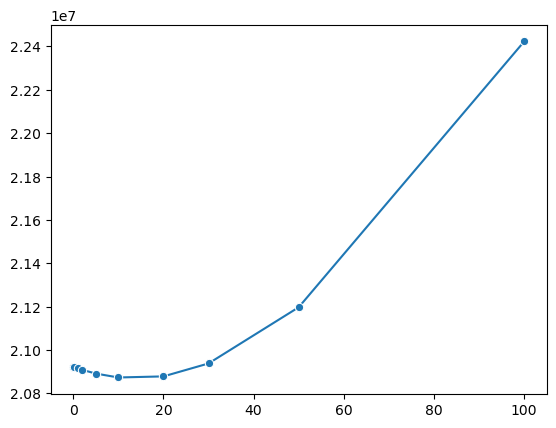

In [7]:
import seaborn as sns 

alpha  = [0.001,0.1,1,2,5,10,20,30,50,100]
mses = []

for a in alpha :
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train , y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test , y_pred)
    print(f"MSE for alpha = {a}" , mse)
    mses.append(mse)

sns.lineplot(x= alpha , y = mses , marker = "o")

In [15]:
from sklearn.linear_model import LassoCV
a = [0.001,0.1,1,2,5,10,20,30,50,100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42

)
lasso_cv_model.fit(X_train , y_train)
print("Best Alpha Value : ",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("mean_squared_error : ",mse)
print ("r_squared value is :",r2)

Best Alpha Value :  0.001
mean_squared_error :  20922599.87103596
r_squared value is : 0.8652317499151699
